In [1]:
import os
import numpy as np
import pandas as pd

path_this = os.path.dirname(os.path.abspath(__name__))
path_root = os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [2]:
df_dataset = pd.read_csv(os.path.join(path_dataset,'preprocessed_dataset.csv'))
demograph_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_features = [
	'PhoneService', 'MultipleLines', 'InternetService', 
	'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
	'TechSupport', 'StreamingTV', 'StreamingMovies']
membership_features = [
	'Contract', 'PaperlessBilling', 'PaymentMethod', 
	'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']

print("Customer Demography")
display(df_dataset.loc[
	:, ['customerID'] + demograph_features + ['Churn']].sample(5, random_state=42))
print("Service")
display(df_dataset.loc[
	:, ['customerID'] + services_features + ['Churn']].sample(5, random_state=42))
print("Membership")
display(df_dataset.loc[
	:, ['customerID'] + membership_features].sample(5, random_state=42))

Customer Demography


,customerID,gender,SeniorCitizen,Partner,Dependents,Churn
2476,6614-ywysc,male,yes,yes,no,0
6773,9546-kdtrb,female,no,no,no,0
6116,0871-uruwo,male,no,yes,no,1
3047,5151-hqrdg,male,no,yes,no,0
4092,6624-jdrds,female,no,no,no,0


Service


,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
2476,6614-ywysc,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6773,9546-kdtrb,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6116,0871-uruwo,yes,yes,fiber optic,no,no,yes,no,yes,yes,1
3047,5151-hqrdg,yes,yes,dsl,yes,no,no,no,no,no,0
4092,6624-jdrds,no,no phone service,dsl,yes,no,no,no,no,no,0


Membership


,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure,Churn
2476,6614-ywysc,two year,no,bank transfer (automatic),25.00,1501.75,61,0
6773,9546-kdtrb,month-to-month,no,bank transfer (automatic),24.70,465.85,19,0
6116,0871-uruwo,month-to-month,yes,credit card (automatic),102.25,1359.00,13,1
3047,5151-hqrdg,month-to-month,yes,mailed check,55.05,2030.75,37,0
4092,6624-jdrds,month-to-month,no,bank transfer (automatic),29.45,161.45,6,0


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
TARGET_COL = 'Churn'
# drop unnecessary columns
X = df_dataset.drop(columns=[TARGET_COL, 'customerID', 'TotalCharges'])
y = df_dataset[TARGET_COL]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()
print(numerical_features)
print(categorical_features)

['tenure', 'MonthlyCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
	n_estimators=300,
	max_depth=10,
	min_samples_leaf=50,
	class_weight={0: 1, 1: 3},
	random_state=42,
	n_jobs=-1
)

pipeline_rf = Pipeline(steps=[
("preprocessing", preprocessor),
("model", rf_model)
])

pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [38]:
from sklearn.metrics import (
	accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,
	classification_report, roc_auc_score, log_loss, RocCurveDisplay)


In [45]:
METRIC_RESULT = []

def get_model_result(y_test, y_pred, y_proba, round_to=3, **kwargs):
	buffer = {
		'accuracy': round(accuracy_score(y_test, y_pred), round_to),
		'precision': round(precision_score(y_test, y_pred), round_to),
		'recall': round(recall_score(y_test, y_pred), round_to),
		'f1_score': round(f1_score(y_test, y_pred), round_to),
		'roc_auc': round(roc_auc_score(y_test, y_proba), round_to),
		'log_loss': round(log_loss(y_test, y_proba), round_to)
	}
	for key, value in kwargs.items():
		buffer[key] = value

	buffer.update({
		'confusion_matrix': confusion_matrix(y_test, y_pred),
		'classification_report': classification_report(y_test, y_pred)})
	return buffer

In [46]:
y_proba_pipeline_rf = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_pipeline_rf = pipeline_rf.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': {'n_estimators': 300,
		'max_depth': 10,
		'min_samples_leaf': 50,
		'class_weight': {0: 1, 1: 3},
		'random_state': 42,
		'n_jobs': -1},
	'model_name': 'baseline model'
}
buffer_result = get_model_result(y_test, y_pred_pipeline_rf, 
								 y_proba_pipeline_rf, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.81
log-loss score	: 0.51
roc_auc score	: 0.84
confusion matrix:
[[720 313]
 [ 72 302]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



---
### Model Calibration

In [47]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
calibrated_rf = CalibratedClassifierCV(
    estimator=pipeline_rf,
    method="sigmoid",
    cv=skf
)

calibrated_rf.fit(X_train, y_train)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, 

In [48]:
y_proba_calibrated_rf = calibrated_rf.predict_proba(X_test)[:, 1]
y_pred_calibrated_rf = calibrated_rf.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': {'n_estimators': 300,
		'max_depth': 10,
		'min_samples_leaf': 50,
		'class_weight': {0: 1, 1: 3},
		'random_state': 42,
		'n_jobs': -1},
	'model_name': 'calibrated baseline model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_rf, 
								 y_proba_calibrated_rf, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.56
log-loss score	: 0.43
roc_auc score	: 0.84
confusion matrix:
[[916 117]
 [163 211]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.73      1407
weighted avg       0.79      0.80      0.80      1407



---
### Visualisasi hasil kalibrasi

In [13]:
y_proba_calibrated = calibrated_rf.predict_proba(X_test)[:, 1]
y_proba_raw = pipeline_rf.predict_proba(X_test)[:, 1]

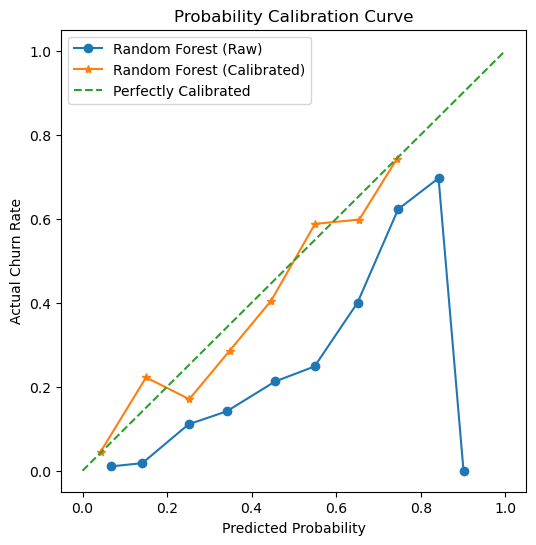

In [14]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, y_proba_raw, n_bins=10
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_proba_calibrated, n_bins=10
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Random Forest (Raw)')
plt.plot(prob_pred_cal, prob_true_cal, marker='*', label='Random Forest (Calibrated)')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Churn Rate")
plt.legend()
plt.title("Probability Calibration Curve")
plt.show()


### penentuan threshold berdasarkan F1-Score

In [19]:
def get_best_threshold_by_f1(y_test, y_pred):
	thresholds, step = np.linspace(0.1, 1.0, 50, retstep=True)
	best_f1 = 0
	best_t = 0

	for t in thresholds:
		y_pred_t = (y_pred >= t).astype(int)
		f1 = f1_score(y_test, y_pred_t)

		if f1 > best_f1:
			best_f1 = f1
			best_t = t

	return best_t, best_f1

In [20]:
best_t, best_f1 = get_best_threshold_by_f1(y_test, y_proba_calibrated_rf)
best_t, best_f1

(np.float64(0.3938775510204082), 0.635036496350365)

In [51]:
y_proba_calibrated_rf = calibrated_rf.predict_proba(X_test)[:, 1]
y_pred_calibrated_rf = (y_proba_calibrated_rf >= best_t).astype(int)
# y_pred_calibrated_rf = calibrated_rf.predict(X_test)

buffer_info = {
	'thresholds': best_t,
	'params': {'n_estimators': 300,
		'max_depth': 10,
		'min_samples_leaf': 50,
		'class_weight': {0: 1, 1: 3},
		'random_state': 42,
		'n_jobs': -1},
	'model_name': 'calibrated & threshold adjusted baseline model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_rf, 
								 y_proba_calibrated_rf, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.76
log-loss score	: 0.43
roc_auc score	: 0.84
confusion matrix:
[[778 255]
 [ 89 285]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



---
# Hyperparameter Tuning Model

In [22]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [3, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", 0.7]
}


In [53]:
from sklearn.model_selection import GridSearchCV

rf_tuned = RandomForestClassifier(
    random_state=42,
    class_weight={0: 1, 1: 3},
    n_jobs=-1
)

tuned_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_tuned)
    ]
)

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 0.7], 'model__min_samples_leaf': [3, 5, ...], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [56]:
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)


Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 300}


In [57]:
y_proba_best_model = best_model.predict_proba(X_test)[:, 1]
# y_pred_best_model = (y_proba_best_model >= best_t).astype(int)
y_pred_best_model = best_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': grid_search.best_params_,
	'model_name': 'tuned model'
}
buffer_result = get_model_result(y_test, y_pred_best_model, 
								 y_proba_best_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.72
log-loss score	: 0.47
roc_auc score	: 0.83
confusion matrix:
[[805 228]
 [106 268]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [55]:
from sklearn.metrics import log_loss, roc_auc_score, recall_score

In [28]:
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

results = [
    {
		'model_name': 'baseline_rf',
        'log_loss': log_loss(y_test, y_proba_pipeline_rf),
        'roc_auc': roc_auc_score(y_test, y_proba_pipeline_rf),
        'recall@0.5': recall_score(y_test, (y_proba_pipeline_rf >= 0.5).astype(int))
    },
    {
		'model_name': 'tuned_rf',
        'log_loss': log_loss(y_test, y_proba_tuned),
        'roc_auc': roc_auc_score(y_test, y_proba_tuned),
        'recall@0.5': recall_score(y_test, (y_proba_tuned >= 0.5).astype(int))
    }
]

pd.DataFrame(results)


,model_name,log_loss,roc_auc,recall@0.5
0,baseline_rf,0.514788,0.836500,0.807487
1,tuned_rf,0.472396,0.830657,0.716578


#### Kalibrasi Hyperparameter Model

In [58]:
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
calibrated_tuned_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=skf
)

calibrated_tuned_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, 

In [60]:
y_proba_calibrated_tuned_model = calibrated_tuned_model.predict_proba(X_test)[:, 1]
# y_pred_calibrated_tuned_model = (y_proba_calibrated_tuned_model >= best_t).astype(int)
y_pred_calibrated_tuned_model = calibrated_tuned_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': grid_search.best_params_,
	'model_name': 'calibrated tuned model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_tuned_model, 
								 y_proba_calibrated_tuned_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.53
log-loss score	: 0.43
roc_auc score	: 0.83
confusion matrix:
[[911 122]
 [176 198]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [62]:
best_t, best_f1 = get_best_threshold_by_f1(y_test, y_proba_calibrated_tuned_model)
best_t, best_f1

(np.float64(0.3020408163265306), 0.6237513873473918)

In [63]:
y_proba_calibrated_tuned_model = calibrated_tuned_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_tuned_model = (y_proba_calibrated_tuned_model >= best_t).astype(int)
# y_pred_calibrated_tuned_model = calibrated_tuned_model.predict(X_test)

buffer_info = {
	'thresholds': best_t,
	'params': grid_search.best_params_,
	'model_name': 'calibrated & threshold adjusted tuned model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_tuned_model, 
								 y_proba_calibrated_tuned_model, 2, **buffer_info)

METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.75
log-loss score	: 0.43
roc_auc score	: 0.83
confusion matrix:
[[787 246]
 [ 93 281]]
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



In [64]:
df_result = pd.DataFrame(METRIC_RESULT)
df_result.loc[
	:, ['model_name', 'log_loss', 'recall', 'precision', 'f1_score', 'roc_auc']].sort_values(
		by=['log_loss', 'recall'], ascending=[True, False])

,model_name,log_loss,recall,precision,f1_score,roc_auc
2,calibrated & threshold adjusted baseline model,0.43,0.76,0.53,0.62,0.84
5,calibrated & threshold adjusted tuned model,0.43,0.75,0.53,0.62,0.83
1,calibrated baseline model,0.43,0.56,0.64,0.60,0.84
4,calibrated tuned model,0.43,0.53,0.62,0.57,0.83
3,tuned model,0.47,0.72,0.54,0.62,0.83
0,baseline model,0.51,0.81,0.49,0.61,0.84


---
## Cost-based Thresholding

In [106]:
from sklearn.metrics import confusion_matrix

COST_FN = 1_000_000
COST_FP = 550_000

def expected_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # print(tn, fp, fn, tp)
    return fp * COST_FP + fn * COST_FN


#### Baseline calibrated model

In [107]:
y_proba_calibrated_rf = calibrated_rf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 1.0, 101)

costs = [
    expected_cost(y_test, y_proba_calibrated_rf, t)
    for t in thresholds
]

optimal_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

optimal_threshold, min_cost


(np.float64(0.388), np.int64(216050000))

In [100]:
baseline_cost = expected_cost(y_test, y_proba_calibrated_rf, 0.5)

print(f"Cost @ threshold 0.5\t\t: {baseline_cost:,}")
print(f"Cost @ optimal threshold\t: {min_cost:,} (threshold: {round(optimal_threshold,2)})")
print(f"Cost reduction\t\t\t: {baseline_cost - min_cost:,}")


Cost @ threshold 0.5		: 76,900,000
Cost @ optimal threshold	: 58,300,000 (threshold: 0.15)
Cost reduction			: 18,600,000


In [101]:
y_proba_calibrated_rf = calibrated_rf.predict_proba(X_test)[:, 1]
y_pred_calibrated_rf = (y_proba_calibrated_rf >= optimal_threshold).astype(int)
# y_pred_calibrated_rf = calibrated_rf.predict(X_test)

buffer_info = {
	'thresholds': optimal_threshold,
	'params': grid_search.best_params_,
	'model_name': 'calibrated & threshold adjusted tuned model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_rf, 
								 y_proba_calibrated_rf, 2, **buffer_info)

# METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.9
log-loss score	: 0.43
roc_auc score	: 0.84
confusion matrix:
[[606 427]
 [ 39 335]]
              precision    recall  f1-score   support

           0       0.94      0.59      0.72      1033
           1       0.44      0.90      0.59       374

    accuracy                           0.67      1407
   macro avg       0.69      0.74      0.66      1407
weighted avg       0.81      0.67      0.69      1407



#### Tuned calibrated model

In [72]:
y_proba_calibrated_tuned_model = calibrated_tuned_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 1.0, 101)

costs = [
    expected_cost(y_test, y_proba_calibrated_tuned_model, t)
    for t in thresholds
]

optimal_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

optimal_threshold, min_cost


(np.float64(0.11800000000000001), np.int64(78800000))

In [73]:
baseline_cost = expected_cost(y_test, y_proba_calibrated_tuned_model, 0.5)

print(f"Cost @ threshold 0.5\t\t: {baseline_cost:,}")
print(f"Cost @ optimal threshold\t: {min_cost:,} (threshold: {round(optimal_threshold,2)})")
print(f"Cost reduction\t\t\t: {baseline_cost - min_cost:,}")


Cost @ threshold 0.5		: 188,200,000
Cost @ optimal threshold	: 78,800,000 (threshold: 0.12)
Cost reduction			: 109,400,000


In [32]:
best_t, best_f1 = get_best_threshold_by_f1(y_test, y_proba_calibrated_tuned_model)
best_t, best_f1

(np.float64(0.3020408163265306), 0.6237513873473918)

In [33]:
y_proba_calibrated_tuned_model = calibrated_tuned_model.predict_proba(X_test)[:, 1]
y_pred_calibrated_tuned_model = (y_proba_calibrated_tuned_model >= best_t).astype(int)
# y_pred_calibrated_tuned_model = calibrated_tuned_model.predict(X_test)

buffer_info = {
	'thresholds': 0.5,
	'params': {'class_weight': 'balanced'},
	'model_name': 'baseline model'
}
buffer_result = get_model_result(y_test, y_pred_calibrated_tuned_model, 
								 y_proba_calibrated_tuned_model, 2, **buffer_info)

# METRIC_RESULT.append(buffer_result)
print(f"recall score\t: {buffer_result['recall']}")
print(f"log-loss score\t: {buffer_result['log_loss']}")
print(f"roc_auc score\t: {buffer_result['roc_auc']}")
print(f"confusion matrix:\n{buffer_result['confusion_matrix']}")
print(buffer_result['classification_report'])

recall score	: 0.75
log-loss score	: 0.43
roc_auc score	: 0.83
confusion matrix:
[[787 246]
 [ 93 281]]
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



In [ ]:
import numpy as np
import pandas as pd

def expected_cost(
    y_true, y_proba, threshold,
    cost_fn, cost_fp, success_rate=1.0
):
    """
    Expected cost calculation with optional success rate.

    Parameters:
    - y_true: ground truth labels (0/1)
    - y_proba: predicted probabilities
    - threshold: decision threshold
    - cost_fn: loss from churn (False Negative)
    - cost_fp: cost of unnecessary retention (False Positive)
    - success_rate: probability retention prevents churn
    """

    y_pred = (y_proba >= threshold).astype(int)

    fn = np.sum((y_true == 1) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    # Churn that still happens despite retention
    failed_retention = tp * (1 - success_rate)

    total_cost = (
        fn * cost_fn +
        fp * cost_fp +
        failed_retention * cost_fn
    )

    return total_cost

In [ ]:
def find_optimal_threshold(
    y_true,
    y_proba,
    cost_fn,
    cost_fp,
    success_rate=1.0,
    threshold_grid=None
):

    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.99, 99)

    costs = []

    for t in threshold_grid:
        cost = expected_cost(
            y_true, y_proba, threshold=t,
            cost_fn=cost_fn, cost_fp=cost_fp,
            success_rate=success_rate
        )
        costs.append(cost)

    costs = np.array(costs)
    optimal_idx = np.argmin(costs)

    return {
        "optimal_threshold": threshold_grid[optimal_idx],
        "minimum_cost": costs[optimal_idx],
        # "thresholds": threshold_grid,
        "costs": costs
    }


In [ ]:
def sensitivity_success_rate(
    y_true, y_proba,
    cost_fn, cost_fp, success_rates):

    results = []

    for s in success_rates:
        result = find_optimal_threshold(
            y_true, y_proba,
            cost_fn, cost_fp, success_rate=s)

        results.append({
            "success_rate": s,
            "optimal_threshold": result["optimal_threshold"],
            "minimum_cost": result["minimum_cost"]
        })

    return pd.DataFrame(results)


In [ ]:
y_proba_calibrated_rf = calibrated_rf.predict_proba(X_test)[:, 1]
success_rates = [1.0, 0.8, 0.6, 0.5, 0.4, 0.3]

df_success_sensitivity = sensitivity_success_rate(
    y_test, y_proba_calibrated_rf,
    cost_fn=1_000_000, cost_fp=100_000,
    success_rates=success_rates
)

print(df_success_sensitivity)


   success_rate  optimal_threshold  minimum_cost
0           1.0               0.05    72100000.0
1           0.8               0.09   144900000.0
2           0.6               0.09   215300000.0
3           0.5               0.17   249100000.0
4           0.4               0.17   282300000.0
5           0.3               0.31   313500000.0


In [115]:
import matplotlib.pyplot as plt

def plot_cost_curves(
    y_true,
    y_proba,
    cost_fn,
    cost_fp,
    success_rates
):

    threshold_grid = np.linspace(0.01, 0.99, 99)

    plt.figure(figsize=(8, 5))

    for s in success_rates:
        costs = [
            expected_cost(
                y_true,
                y_proba,
                t,
                cost_fn,
                cost_fp,
                success_rate=s
            )
            for t in threshold_grid
        ]

        plt.plot(threshold_grid, costs, label=f"s={s}")

    plt.xlabel("Threshold")
    plt.ylabel("Expected Cost")
    plt.title("Expected Cost vs Threshold (Sensitivity to Success Rate)")
    plt.legend()
    plt.show()


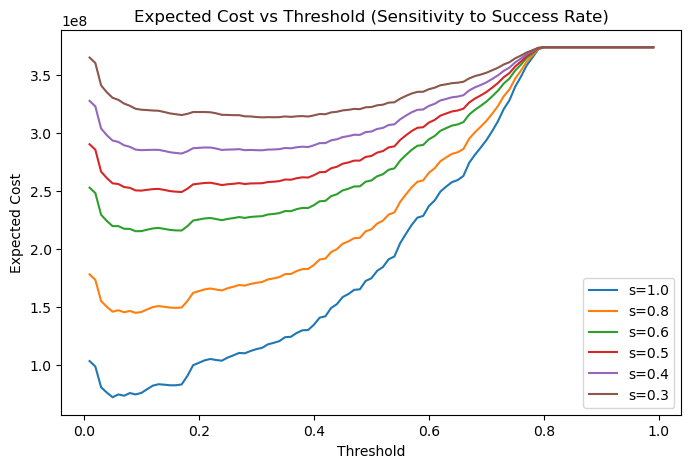

In [116]:
plot_cost_curves( y_test,
    y_proba_calibrated_rf,
    cost_fn=1_000_000,
    cost_fp=100_000,
    success_rates=success_rates)